In [1]:
# ============================
# Cell 1: Imports & Setup
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import snntorch as snn
from snntorch import spikegen, surrogate
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All imports successful ✓")

Using device: cuda
All imports successful ✓


In [8]:
# ============================
# Cell 2: Load MNIST
# ============================

# ANN: normalized (better gradient flow)
transform_ann = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# SNN: raw [0,1] values (correct latency encoding)
transform_snn = transforms.Compose([
    transforms.ToTensor()
])

# ANN dataloaders
train_dataset_ann = datasets.MNIST(root='./data', train=True,  download=True, transform=transform_ann)
test_dataset_ann  = datasets.MNIST(root='./data', train=False, download=True, transform=transform_ann)
train_loader_ann  = DataLoader(train_dataset_ann, batch_size=64, shuffle=True)
test_loader_ann   = DataLoader(test_dataset_ann,  batch_size=64, shuffle=False)

# SNN dataloaders
train_dataset_snn = datasets.MNIST(root='./data', train=True,  download=True, transform=transform_snn)
test_dataset_snn  = datasets.MNIST(root='./data', train=False, download=True, transform=transform_snn)
train_loader_snn  = DataLoader(train_dataset_snn, batch_size=64, shuffle=True)
test_loader_snn   = DataLoader(test_dataset_snn,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_dataset_ann)}")
print(f"Test samples     : {len(test_dataset_ann)}")
print(f"ANN data range   : [{train_dataset_ann[0][0].min():.2f}, {train_dataset_ann[0][0].max():.2f}]")
print(f"SNN data range   : [{train_dataset_snn[0][0].min():.2f}, {train_dataset_snn[0][0].max():.2f}]")
print("MNIST loaded ✓")

Training samples : 60000
Test samples     : 10000
ANN data range   : [-0.42, 2.82]
SNN data range   : [0.00, 1.00]
MNIST loaded ✓


In [9]:
# ============================
# Cell 3: Mini CNN ANN
# ============================
class Mini_CNN_ANN(nn.Module):
    def __init__(self):
        super(Mini_CNN_ANN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 28x28 → 14x14

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 14x14 → 7x7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

ann_cnn = Mini_CNN_ANN().to(device)
total_params = sum(p.numel() for p in ann_cnn.parameters())
print(ann_cnn)
print(f"\nTotal parameters: {total_params:,}")

Mini_CNN_ANN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim

In [10]:
# ============================
# Cell 4: Train ANN CNN
# ============================
def train_ann(model, train_loader, test_loader, epochs=10, model_name="ANN_CNN"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        acc = 100 * correct / total
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['test_acc'].append(acc)
        print(f"[{model_name}] Epoch {epoch+1:2d}/10 | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

    return history

ann_cnn_history = train_ann(ann_cnn, train_loader_ann, test_loader_ann, 
                             epochs=10, model_name="ANN_CNN")
print("\nANN CNN Training Complete ✓")

[ANN_CNN] Epoch  1/10 | Loss: 0.1422 | Acc: 98.20%
[ANN_CNN] Epoch  2/10 | Loss: 0.0632 | Acc: 99.05%
[ANN_CNN] Epoch  3/10 | Loss: 0.0476 | Acc: 99.35%
[ANN_CNN] Epoch  4/10 | Loss: 0.0399 | Acc: 99.18%
[ANN_CNN] Epoch  5/10 | Loss: 0.0348 | Acc: 99.15%
[ANN_CNN] Epoch  6/10 | Loss: 0.0198 | Acc: 99.46%
[ANN_CNN] Epoch  7/10 | Loss: 0.0174 | Acc: 99.43%
[ANN_CNN] Epoch  8/10 | Loss: 0.0155 | Acc: 99.54%
[ANN_CNN] Epoch  9/10 | Loss: 0.0137 | Acc: 99.46%
[ANN_CNN] Epoch 10/10 | Loss: 0.0127 | Acc: 99.42%

ANN CNN Training Complete ✓


In [11]:
# ============================
# Cell 5: Latency Encoder
# ============================
def latency_encode(x, num_steps, threshold=0.1):
    """
    True latency coding:
    - Bright pixels → fire EARLY
    - Dark pixels   → fire LATE or never
    - Each pixel fires AT MOST ONCE → maximum sparsity
    """
    batch_size, channels, height, width = x.shape
    spike_train = torch.zeros(num_steps, batch_size, channels, height, width, device=x.device)

    fire_times = ((1.0 - x) * (num_steps - 1)).round().long()
    fire_mask  = x > threshold

    for t in range(num_steps):
        spike_train[t] = ((fire_times == t) & fire_mask).float()

    return spike_train  # [num_steps, batch, 1, 28, 28]

# Quick test
test_img   = torch.rand(4, 1, 28, 28).to(device)
test_spikes = latency_encode(test_img, num_steps=25)
total_spikes = test_spikes.sum().item()
possible     = 25 * 4 * 1 * 28 * 28
print(f"Latency encoding test ✓")
print(f"Spike density : {total_spikes/possible:.4f}")
print(f"Sparsity      : {1 - total_spikes/possible:.4f}")

Latency encoding test ✓
Spike density : 0.0359
Sparsity      : 0.9641


In [18]:
# ============================
# Cell 6: Mini CNN SNN Temporal
# ============================
spike_grad = surrogate.fast_sigmoid(slope=25)

class Mini_CNN_SNN(nn.Module):
    def __init__(self, num_steps=25, threshold=0.3):
        super(Mini_CNN_SNN, self).__init__()
        self.num_steps = num_steps
        self.threshold = threshold

        # Block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.lif1  = snn.Leaky(beta=0.5, threshold=self.threshold, 
                                learn_beta=True, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.lif2  = snn.Leaky(beta=0.5, threshold=self.threshold,
                                learn_beta=True, spike_grad=spike_grad)

        self.pool1 = nn.MaxPool2d(2, 2)  # 28x28 → 14x14

        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.lif3  = snn.Leaky(beta=0.5, threshold=self.threshold,
                                learn_beta=True, spike_grad=spike_grad)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(64)
        self.lif4  = snn.Leaky(beta=0.5, threshold=self.threshold,
                                learn_beta=True, spike_grad=spike_grad)

        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 → 7x7

        # Classifier
        self.flatten = nn.Flatten()
        self.fc1  = nn.Linear(64 * 7 * 7, 256)
        self.lif5 = snn.Leaky(beta=0.5, threshold=self.threshold,
                               learn_beta=True, spike_grad=spike_grad)
        self.fc2  = nn.Linear(256, 10)
        self.lif6 = snn.Leaky(beta=0.5, threshold=self.threshold,
                               learn_beta=True, spike_grad=spike_grad)

    def forward(self, x):
        # Init membrane potentials
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem5 = self.lif5.init_leaky()
        mem6 = self.lif6.init_leaky()

        # Latency encode — keeps 2D spatial structure
        spike_train = latency_encode(x, self.num_steps)

        mem6_sum = torch.zeros(x.size(0), 10, device=x.device)

        for t in range(self.num_steps):
            spk_in = spike_train[t]   # [batch, 1, 28, 28]

            # Block 1
            cur1 = self.bn1(self.conv1(spk_in))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.bn2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2 = self.pool1(spk2)

            # Block 2
            cur3 = self.bn3(self.conv3(spk2))
            spk3, mem3 = self.lif3(cur3, mem3)

            cur4 = self.bn4(self.conv4(spk3))
            spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = self.pool2(spk4)

            # Classifier
            spk4_flat = self.flatten(spk4)
            cur5 = self.fc1(spk4_flat)
            spk5, mem5 = self.lif5(cur5, mem5)

            cur6 = self.fc2(spk5)
            spk6, mem6 = self.lif6(cur6, mem6)

            mem6_sum += mem6

        return mem6_sum

cnn_snn = Mini_CNN_SNN(num_steps=25, threshold=0.3).to(device)
total_params = sum(p.numel() for p in cnn_snn.parameters())
print(f"Mini CNN SNN ready ✓")
print(f"Total parameters: {total_params:,}")

Mini CNN SNN ready ✓
Total parameters: 871,024


In [13]:
# ============================
# Cell 7: Train Mini CNN SNN
# ============================
def train_cnn_snn(model, train_loader, test_loader, epochs=15, model_name="Mini_CNN_SNN"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        acc = 100 * correct / total
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['test_acc'].append(acc)
        print(f"[{model_name}] Epoch {epoch+1:2d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

    return history

cnn_snn_history = train_cnn_snn(cnn_snn, train_loader_snn, test_loader_snn,
                                 epochs=15, model_name="Mini_CNN_SNN")
print("\nMini CNN SNN Training Complete ✓")

[Mini_CNN_SNN] Epoch  1/15 | Loss: 1.3974 | Acc: 80.81%
[Mini_CNN_SNN] Epoch  2/15 | Loss: 0.3866 | Acc: 93.12%
[Mini_CNN_SNN] Epoch  3/15 | Loss: 0.2853 | Acc: 91.39%
[Mini_CNN_SNN] Epoch  4/15 | Loss: 0.2219 | Acc: 88.57%
[Mini_CNN_SNN] Epoch  5/15 | Loss: 0.1990 | Acc: 92.69%
[Mini_CNN_SNN] Epoch  6/15 | Loss: 0.1409 | Acc: 96.32%
[Mini_CNN_SNN] Epoch  7/15 | Loss: 0.1244 | Acc: 95.23%
[Mini_CNN_SNN] Epoch  8/15 | Loss: 0.1144 | Acc: 96.10%
[Mini_CNN_SNN] Epoch  9/15 | Loss: 0.1076 | Acc: 95.86%
[Mini_CNN_SNN] Epoch 10/15 | Loss: 0.1017 | Acc: 96.36%
[Mini_CNN_SNN] Epoch 11/15 | Loss: 0.0796 | Acc: 96.53%
[Mini_CNN_SNN] Epoch 12/15 | Loss: 0.0706 | Acc: 97.04%
[Mini_CNN_SNN] Epoch 13/15 | Loss: 0.0660 | Acc: 96.62%
[Mini_CNN_SNN] Epoch 14/15 | Loss: 0.0629 | Acc: 97.23%
[Mini_CNN_SNN] Epoch 15/15 | Loss: 0.0613 | Acc: 97.30%

Mini CNN SNN Training Complete ✓


In [21]:
cnn_snn_2 = Mini_CNN_SNN(num_steps=25, threshold=0.5).to(device)

cnn_snn_history_2 = train_cnn_snn(cnn_snn_2, train_loader_snn, test_loader_snn,
                                   epochs=15, model_name="Mini_CNN_SNN_thr05")
print("\nMini CNN SNN (threshold=0.5) Training Complete ✓")

[Mini_CNN_SNN_thr05] Epoch  1/15 | Loss: 1.0478 | Acc: 90.03%
[Mini_CNN_SNN_thr05] Epoch  2/15 | Loss: 0.3245 | Acc: 92.42%
[Mini_CNN_SNN_thr05] Epoch  3/15 | Loss: 0.2319 | Acc: 93.12%
[Mini_CNN_SNN_thr05] Epoch  4/15 | Loss: 0.1933 | Acc: 95.54%
[Mini_CNN_SNN_thr05] Epoch  5/15 | Loss: 0.1575 | Acc: 95.34%
[Mini_CNN_SNN_thr05] Epoch  6/15 | Loss: 0.1072 | Acc: 97.52%
[Mini_CNN_SNN_thr05] Epoch  7/15 | Loss: 0.0929 | Acc: 97.51%
[Mini_CNN_SNN_thr05] Epoch  8/15 | Loss: 0.0807 | Acc: 97.94%
[Mini_CNN_SNN_thr05] Epoch  9/15 | Loss: 0.0743 | Acc: 97.57%
[Mini_CNN_SNN_thr05] Epoch 10/15 | Loss: 0.0680 | Acc: 97.98%
[Mini_CNN_SNN_thr05] Epoch 11/15 | Loss: 0.0499 | Acc: 98.39%
[Mini_CNN_SNN_thr05] Epoch 12/15 | Loss: 0.0472 | Acc: 98.14%
[Mini_CNN_SNN_thr05] Epoch 13/15 | Loss: 0.0412 | Acc: 98.62%
[Mini_CNN_SNN_thr05] Epoch 14/15 | Loss: 0.0390 | Acc: 98.43%
[Mini_CNN_SNN_thr05] Epoch 15/15 | Loss: 0.0357 | Acc: 98.35%

Mini CNN SNN (threshold=0.5) Training Complete ✓


In [23]:
# ============================
# Save Models & Histories
# ============================
import json
import os

save_dir = './saved_models'
os.makedirs(save_dir, exist_ok=True)

# Save model weights
torch.save(ann_cnn.state_dict(),    f'{save_dir}/ann_cnn.pth')
torch.save(cnn_snn.state_dict(),    f'{save_dir}/cnn_snn_thr03.pth')
torch.save(cnn_snn_2.state_dict(),  f'{save_dir}/cnn_snn_thr05.pth')

# Save training histories
with open(f'{save_dir}/ann_cnn_history.json', 'w') as f:
    json.dump(ann_cnn_history, f)

with open(f'{save_dir}/cnn_snn_history.json', 'w') as f:
    json.dump(cnn_snn_history, f)

with open(f'{save_dir}/cnn_snn_history_2.json', 'w') as f:
    json.dump(cnn_snn_history_2, f)

print("All models saved ✓")
print(f"  ann_cnn          → {save_dir}/ann_cnn.pth")
print(f"  cnn_snn (thr03)  → {save_dir}/cnn_snn_thr03.pth")
print(f"  cnn_snn_2 (thr05)→ {save_dir}/cnn_snn_thr05.pth")

All models saved ✓
  ann_cnn          → ./saved_models/ann_cnn.pth
  cnn_snn (thr03)  → ./saved_models/cnn_snn_thr03.pth
  cnn_snn_2 (thr05)→ ./saved_models/cnn_snn_thr05.pth


In [24]:
cnn_snn_3 = Mini_CNN_SNN(num_steps=25, threshold=0.7).to(device)

cnn_snn_history_3 = train_cnn_snn(cnn_snn_3, train_loader_snn, test_loader_snn,
                                   epochs=15, model_name="Mini_CNN_SNN_thr07")
print("\nMini CNN SNN (threshold=0.7) Training Complete ✓")

[Mini_CNN_SNN_thr07] Epoch  1/15 | Loss: 0.8410 | Acc: 90.08%
[Mini_CNN_SNN_thr07] Epoch  2/15 | Loss: 0.2289 | Acc: 94.31%
[Mini_CNN_SNN_thr07] Epoch  3/15 | Loss: 0.1791 | Acc: 93.72%
[Mini_CNN_SNN_thr07] Epoch  4/15 | Loss: 0.1619 | Acc: 94.99%
[Mini_CNN_SNN_thr07] Epoch  5/15 | Loss: 0.1288 | Acc: 97.53%
[Mini_CNN_SNN_thr07] Epoch  6/15 | Loss: 0.0812 | Acc: 98.24%
[Mini_CNN_SNN_thr07] Epoch  7/15 | Loss: 0.0688 | Acc: 98.34%
[Mini_CNN_SNN_thr07] Epoch  8/15 | Loss: 0.0596 | Acc: 98.41%
[Mini_CNN_SNN_thr07] Epoch  9/15 | Loss: 0.0594 | Acc: 98.27%
[Mini_CNN_SNN_thr07] Epoch 10/15 | Loss: 0.0548 | Acc: 97.83%
[Mini_CNN_SNN_thr07] Epoch 11/15 | Loss: 0.0393 | Acc: 98.57%
[Mini_CNN_SNN_thr07] Epoch 12/15 | Loss: 0.0324 | Acc: 98.67%
[Mini_CNN_SNN_thr07] Epoch 13/15 | Loss: 0.0332 | Acc: 98.70%
[Mini_CNN_SNN_thr07] Epoch 14/15 | Loss: 0.0300 | Acc: 98.65%
[Mini_CNN_SNN_thr07] Epoch 15/15 | Loss: 0.0270 | Acc: 98.68%

Mini CNN SNN (threshold=0.7) Training Complete ✓


In [25]:
torch.save(cnn_snn_3.state_dict(), './saved_models/cnn_snn_thr07.pth')

with open('./saved_models/cnn_snn_history_3.json', 'w') as f:
    json.dump(cnn_snn_history_3, f)

print("thr07 model saved ✓")

thr07 model saved ✓


In [34]:
cnn_snn = Mini_CNN_SNN(num_steps=25, threshold=0.3).to(device)

cnn_snn_history = train_cnn_snn(cnn_snn, train_loader_snn, test_loader_snn,
                                   epochs=15, model_name="Mini_CNN_SNN_thr03")
print("\nMini CNN SNN (threshold=0.3) Training Complete ✓")

[Mini_CNN_SNN_thr03] Epoch  1/15 | Loss: 1.3778 | Acc: 91.33%
[Mini_CNN_SNN_thr03] Epoch  2/15 | Loss: 0.3091 | Acc: 94.36%
[Mini_CNN_SNN_thr03] Epoch  3/15 | Loss: 0.2380 | Acc: 93.17%
[Mini_CNN_SNN_thr03] Epoch  4/15 | Loss: 0.1873 | Acc: 95.81%
[Mini_CNN_SNN_thr03] Epoch  5/15 | Loss: 0.1618 | Acc: 96.38%
[Mini_CNN_SNN_thr03] Epoch  6/15 | Loss: 0.1117 | Acc: 96.79%
[Mini_CNN_SNN_thr03] Epoch  7/15 | Loss: 0.0940 | Acc: 97.36%
[Mini_CNN_SNN_thr03] Epoch  8/15 | Loss: 0.0858 | Acc: 96.95%
[Mini_CNN_SNN_thr03] Epoch  9/15 | Loss: 0.0794 | Acc: 97.16%
[Mini_CNN_SNN_thr03] Epoch 10/15 | Loss: 0.0730 | Acc: 97.21%
[Mini_CNN_SNN_thr03] Epoch 11/15 | Loss: 0.0567 | Acc: 97.78%
[Mini_CNN_SNN_thr03] Epoch 12/15 | Loss: 0.0516 | Acc: 97.82%
[Mini_CNN_SNN_thr03] Epoch 13/15 | Loss: 0.0463 | Acc: 97.65%
[Mini_CNN_SNN_thr03] Epoch 14/15 | Loss: 0.0429 | Acc: 97.84%
[Mini_CNN_SNN_thr03] Epoch 15/15 | Loss: 0.0408 | Acc: 97.87%

Mini CNN SNN (threshold=0.3) Training Complete ✓


In [35]:
torch.save(cnn_snn.state_dict(), './saved_models/cnn_snn_thr03.pth')

with open('./saved_models/cnn_snn_history_1.json', 'w') as f:
    json.dump(cnn_snn_history, f)

print("thr03 model saved ✓")

thr03 model saved ✓


In [36]:
# Verify all saved files
for thr, path in [('0.3', 'cnn_snn_thr03'), ('0.5', 'cnn_snn_thr05'), ('0.7', 'cnn_snn_thr07')]:
    test_m = Mini_CNN_SNN(num_steps=25, threshold=float(thr)).to(device)
    test_m.load_state_dict(torch.load(f'./saved_models/{path}.pth'))
    acc = evaluate_accuracy(test_m, test_loader_snn)
    print(f"Saved {path}: {acc:.2f}% {'✅' if acc > 90 else '❌ CORRUPTED'}")

Saved cnn_snn_thr03: 97.87% ✅
Saved cnn_snn_thr05: 98.35% ✅
Saved cnn_snn_thr07: 98.68% ✅


In [42]:
bit_widths = [8, 6, 4, 3, 2]
results_all = {'bits': bit_widths, 'ANN_CNN': [],
               'SNN_thr03': [], 'SNN_thr05': [], 'SNN_thr07': []}

print(f"{'Bits':<6} {'ANN_CNN':>10} {'thr=0.3':>10} {'thr=0.5':>10} {'thr=0.7':>10}")
print("-" * 50)

for bits in bit_widths:
    ann_q  = quantize_model(ann_cnn,   bits)
    snn_q1 = quantize_model(cnn_snn,   bits)
    snn_q2 = quantize_model(cnn_snn_2, bits)
    snn_q3 = quantize_model(cnn_snn_3, bits)

    ann_acc  = evaluate_accuracy(ann_q,  test_loader_ann)
    snn_acc1 = evaluate_accuracy(snn_q1, test_loader_snn)
    snn_acc2 = evaluate_accuracy(snn_q2, test_loader_snn)
    snn_acc3 = evaluate_accuracy(snn_q3, test_loader_snn)

    results_all['ANN_CNN'].append(ann_acc)
    results_all['SNN_thr03'].append(snn_acc1)
    results_all['SNN_thr05'].append(snn_acc2)
    results_all['SNN_thr07'].append(snn_acc3)

    print(f"{bits:<6} {ann_acc:>9.2f}% {snn_acc1:>9.2f}% {snn_acc2:>9.2f}% {snn_acc3:>9.2f}%")

print("\nQuantization Analysis Complete ✓")

Bits      ANN_CNN    thr=0.3    thr=0.5    thr=0.7
--------------------------------------------------
8          99.42%     96.81%     97.66%     98.77%
6          99.44%     87.64%     96.05%     85.81%
4          99.50%     62.42%     75.43%     38.32%
3          98.10%     36.66%     17.04%     18.44%
2          75.67%     10.02%     10.10%     15.12%

Quantization Analysis Complete ✓


In [ ]:
# ============================
# Energy Estimation - All Models
# ============================

def estimate_cnn_energy(model_type, spike_density, bits, num_steps=25):
    MAC_ENERGY = 4.6  # pJ
    AC_ENERGY  = 0.9  # pJ

    conv_ops = (32 * 1  * 9 * 28*28) + \
               (32 * 32 * 9 * 28*28) + \
               (64 * 32 * 9 * 14*14) + \
               (64 * 64 * 9 * 14*14)
    fc_ops   = (3136 * 256) + (256 * 10)
    total_ops = conv_ops + fc_ops

    bit_factor = bits / 32.0

    if model_type == "ANN":
        energy = total_ops * MAC_ENERGY * bit_factor
    else:
        energy = total_ops * num_steps * spike_density * AC_ENERGY * bit_factor

    return energy

bit_widths = [8, 6, 4, 3, 2]
energy_ann   = []
energy_snn03 = []
energy_snn05 = []
energy_snn07 = []

print(f"{'Bits':<6} {'ANN':>12} {'thr=0.3':>12} {'thr=0.5':>12} {'thr=0.7':>12} {'Best Saving':>12}")
print("-" * 70)

for bits in bit_widths:
    ann_e  = estimate_cnn_energy("ANN", 0,            bits)
    snn_e1 = estimate_cnn_energy("SNN", cnn_density,   bits, 25)
    snn_e2 = estimate_cnn_energy("SNN", cnn_density_2, bits, 25)
    snn_e3 = estimate_cnn_energy("SNN", cnn_density_3, bits, 25)

    energy_ann.append(ann_e)
    energy_snn03.append(snn_e1)
    energy_snn05.append(snn_e2)
    energy_snn07.append(snn_e3)

    best_saving = (1 - min(snn_e1, snn_e2, snn_e3)/ann_e) * 100
    print(f"{bits:<6} {ann_e:>12.0f} {snn_e1:>12.0f} {snn_e2:>12.0f} {snn_e3:>12.0f} {best_saving:>11.1f}%")

print("\nEnergy Estimation Complete ✓")

Bits            ANN      thr=0.3      thr=0.5      thr=0.7  Best Saving
----------------------------------------------------------------------
8          15726848     20423753     14818376     10884232        30.8%
6          11795136     15317815     11113782      8163174        30.8%
4           7863424     10211877      7409188      5442116        30.8%
3           5897568      7658908      5556891      4081587        30.8%
2           3931712      5105938      3704594      2721058        30.8%

Energy Estimation Complete ✓


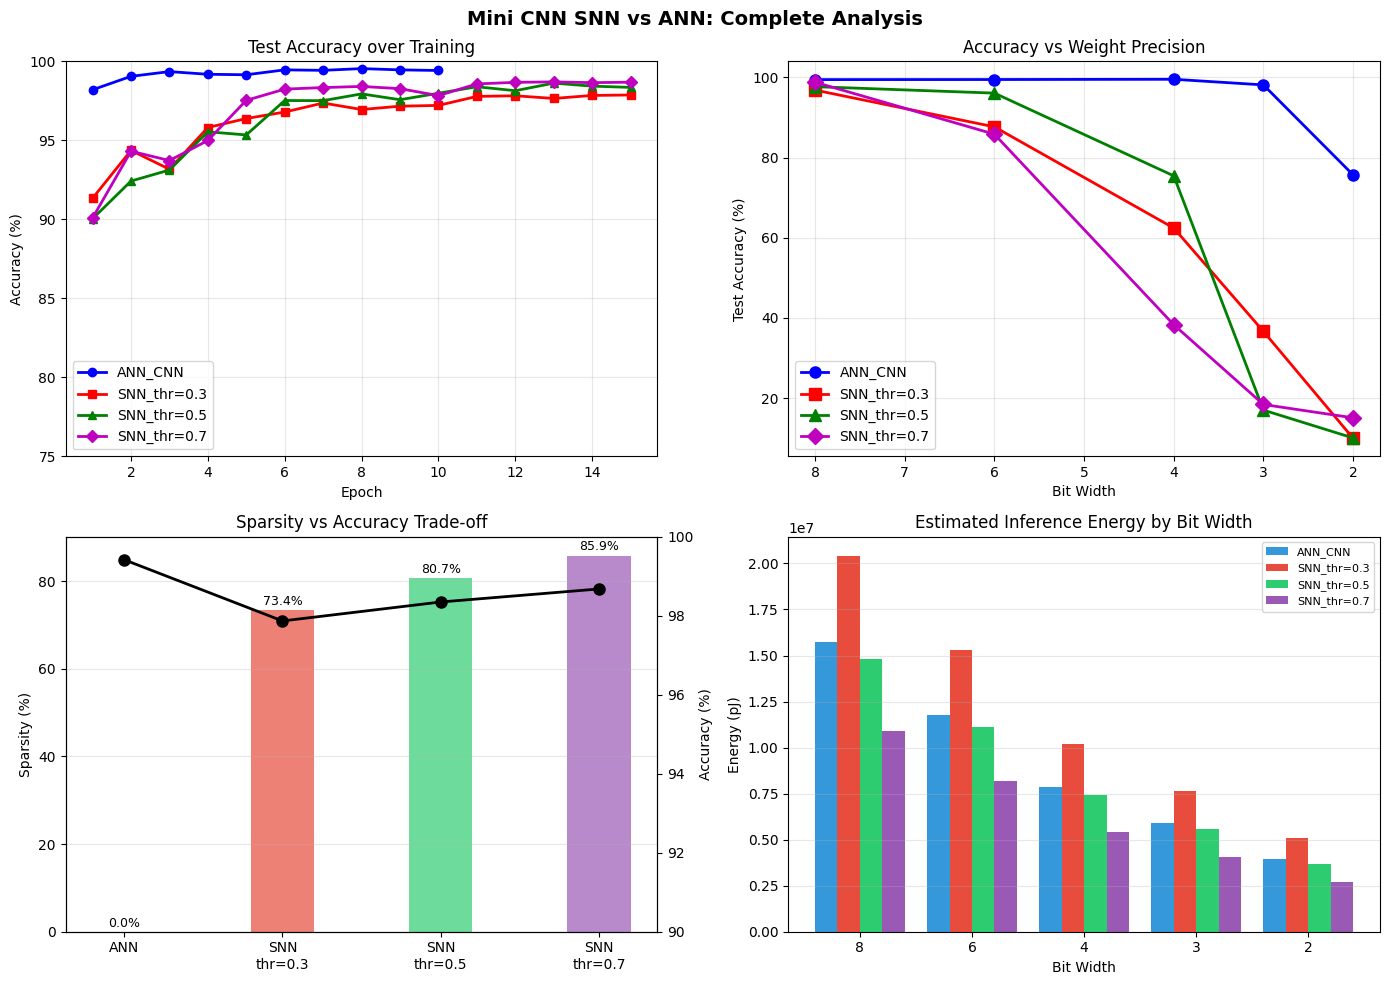

Plot saved as snn_cnn_results_final.png ✓


In [41]:
# ============================
# Final Visualization - All Models
# ============================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mini CNN SNN vs ANN: Complete Analysis', fontsize=14, fontweight='bold')

# --- Plot 1: Training Accuracy ---
ax1 = axes[0, 0]
ax1.plot(range(1, 11), ann_cnn_history['test_acc'],    'b-o', label='ANN_CNN',       linewidth=2)
ax1.plot(range(1, 16), cnn_snn_history['test_acc'],    'r-s', label='SNN_thr=0.3',   linewidth=2)
ax1.plot(range(1, 16), cnn_snn_history_2['test_acc'],  'g-^', label='SNN_thr=0.5',   linewidth=2)
ax1.plot(range(1, 16), cnn_snn_history_3['test_acc'],  'm-D', label='SNN_thr=0.7',   linewidth=2)
ax1.set_title('Test Accuracy over Training')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([75, 100])

# --- Plot 2: Accuracy vs Quantization ---
ax2 = axes[0, 1]
ax2.plot(bit_widths, results_all['ANN_CNN'],    'b-o', label='ANN_CNN',     linewidth=2, markersize=8)
ax2.plot(bit_widths, results_all['SNN_thr03'],  'r-s', label='SNN_thr=0.3', linewidth=2, markersize=8)
ax2.plot(bit_widths, results_all['SNN_thr05'],  'g-^', label='SNN_thr=0.5', linewidth=2, markersize=8)
ax2.plot(bit_widths, results_all['SNN_thr07'],  'm-D', label='SNN_thr=0.7', linewidth=2, markersize=8)
ax2.set_title('Accuracy vs Weight Precision')
ax2.set_xlabel('Bit Width')
ax2.set_ylabel('Test Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

# --- Plot 3: Sparsity & Accuracy Comparison ---
ax3 = axes[1, 0]
models   = ['ANN', 'SNN\nthr=0.3', 'SNN\nthr=0.5', 'SNN\nthr=0.7']
sparsity = [0.0, cnn_sparsity*100, cnn_sparsity_2*100, cnn_sparsity_3*100]
accuracy = [99.42, 97.87, 98.35, 98.68]
x = np.arange(len(models))
ax3b = ax3.twinx()
bars = ax3.bar(x, sparsity, 0.4, color=['#3498db','#e74c3c','#2ecc71','#9b59b6'], alpha=0.7)
ax3b.plot(x, accuracy, 'ko-', linewidth=2, markersize=8, label='Accuracy')
ax3.set_title('Sparsity vs Accuracy Trade-off')
ax3.set_ylabel('Sparsity (%)')
ax3b.set_ylabel('Accuracy (%)')
ax3b.set_ylim([90, 100])
ax3.set_xticks(x)
ax3.set_xticklabels(models)
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, sparsity):
    ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# --- Plot 4: Energy Comparison ---
ax4 = axes[1, 1]
x = np.arange(len(bit_widths))
width = 0.2
ax4.bar(x - 1.5*width, energy_ann,   width, label='ANN_CNN',     color='#3498db')
ax4.bar(x - 0.5*width, energy_snn03, width, label='SNN_thr=0.3', color='#e74c3c')
ax4.bar(x + 0.5*width, energy_snn05, width, label='SNN_thr=0.5', color='#2ecc71')
ax4.bar(x + 1.5*width, energy_snn07, width, label='SNN_thr=0.7', color='#9b59b6')
ax4.set_title('Estimated Inference Energy by Bit Width')
ax4.set_xlabel('Bit Width')
ax4.set_ylabel('Energy (pJ)')
ax4.set_xticks(x)
ax4.set_xticklabels(bit_widths)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('snn_cnn_results_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as snn_cnn_results_final.png ✓")